In [1]:
%load_ext autoreload
%autoreload 2
import os
import time
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

from ag_utils import Corpus
from ag_utils import parse_ag_file
from ag_utils import parse_node_properties

from data import  prepare_raw_pools, load_graphs_from_pool

from models import NN, GCN,TransformerModel,MainModel,DilatedCNNBranch
from model_utils import train, predict_prob, evaluate_performance
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import os
import random
import numpy as np
import torch

# >>>>>>>>>> 固定所有随机种子 <<<<<<<<<<
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # if multi-GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# >>>>>>>>>> End of seed setting <<<<<<<<<<

/root/miniconda3/envs/detr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# parse attack graph file generated by MulVAL tool
attack_graph_path = '../../mulval_attack_graph/ddos_large.dot'
nodes, edges, node_properties = parse_ag_file(attack_graph_path)
node_dict = parse_node_properties(nodes, node_properties)

# save node label into corpus object
corpus = Corpus(node_dict)
num_tokens = corpus.get_num_tokens()
node_features = corpus.get_node_features()
node_types = corpus.get_node_types()
vocab_size = len(corpus.dictionary)
print('vocab_size: ', vocab_size)
print('num_tokens: ', num_tokens)
print('node_features shape: ', node_features.shape)


vocab_size:  119
num_tokens:  715
node_features shape:  torch.Size([205, 119])


In [3]:
# statistics of the encoded attack graph
num_nodes = len(nodes)
print('num_nodes: ', num_nodes)

num_node_features = node_features.shape[1]
print('num_node_features: ', num_node_features)

num_edges = len(edges)
print('num_edges: ', num_edges)

action_nodes = corpus.get_action_nodes()
action_node_idx = list(action_nodes.keys())
num_action_nodes = len(action_node_idx)
print('action_node_idx: ', action_node_idx)
print('num_action_nodes: ', num_action_nodes)

# var 'action_mask' is used to represent the attack scenarios in attack graph (i.e., the privilege nodes)
action_mask = action_node_idx


num_nodes:  205
num_node_features:  119
num_edges:  200
action_node_idx:  [172, 174, 176, 179, 181, 183, 186, 188, 190, 193, 195, 197, 200, 202, 204]
num_action_nodes:  15


In [4]:
# adj matrix and edge index
adj_matrix = torch.zeros(len(nodes), len(nodes))

for edge in edges:
    source_node, target_node = edge
    source_index = nodes.index(source_node)
    target_index = nodes.index(target_node)
    adj_matrix[source_index][target_index] = 1

edge_index = adj_matrix.nonzero().t().contiguous()

assert edge_index.shape[0]==2

In [5]:
# 1. 预切分流量池 (关键：物理隔离)
pools = prepare_raw_pools('../../datasets/CSE-CIC-IDS2018.csv')

# 2. 分别构造训练、验证、测试图集
# 训练集可以多造点，验证/测试集按比例减少
x_b_train, y_b_train, x_m_train, y_m_train = load_graphs_from_pool(pools['train'], 1500, 500, action_node_idx)
x_b_val, y_b_val, x_m_val, y_m_val = load_graphs_from_pool(pools['val'], 200, 50, action_node_idx)
x_b_test, y_b_test, x_m_test, y_m_test = load_graphs_from_pool(pools['test'], 200, 50, action_node_idx)

# 3. 辅助函数：将 load 出来的结果转为最终图格式 (代码复用你之前的 gene_dataset 逻辑)
def build_final_tensor(x_b, y_b, x_m, y_m, num_nodes, action_node_idx):
    rt_meas_dim = x_b.shape[2]
    # 合并良性和恶意
    X = torch.cat([
        torch.zeros(x_b.shape[0], num_nodes, rt_meas_dim).index_copy_(1, torch.tensor(action_node_idx), x_b),
        torch.zeros(x_m.shape[0], num_nodes, rt_meas_dim).index_copy_(1, torch.tensor(action_node_idx), x_m)
    ])
    Y = torch.cat([y_b, y_m])
    return X, Y

X_train_raw, Y_train = build_final_tensor(x_b_train, y_b_train, x_m_train, y_m_train, num_nodes, action_node_idx)
X_val_raw, Y_val = build_final_tensor(x_b_val, y_b_val, x_m_val, y_m_val, num_nodes, action_node_idx)
X_test_raw, Y_test = build_final_tensor(x_b_test, y_b_test, x_m_test, y_m_test, num_nodes, action_node_idx)

# 4. 归一化 (Scaler 必须只 fit 训练集)
scaler = MinMaxScaler()
# 仅提取 action_node_idx 中的真实流量特征来进行拟合
X_traffic_only = X_train_raw[:, action_node_idx, :]
X_traffic_reshaped = X_traffic_only.reshape(-1, X_traffic_only.shape[-1])
scaler.fit(X_traffic_reshaped)

def scale_and_tensor(X_raw, scaler):
    N, N_nodes, Feats = X_raw.shape
    X_scaled = scaler.transform(X_raw.reshape(-1, Feats)).reshape(N, N_nodes, Feats)
    # 【可选修正】为了防止原本填充的 0.0 因为归一化发生偏移，可以强制将非 action 节点重新置零
    # 这对 GAT 和空洞 CNN 的背景噪声控制有好处
    return torch.tensor(X_scaled, dtype=torch.float32)

X_train = scale_and_tensor(X_train_raw, scaler)
X_val = scale_and_tensor(X_val_raw, scaler)
X_test = scale_and_tensor(X_test_raw, scaler)

def scale_and_tensor(X_raw, scaler):
    N, N_nodes, Feats = X_raw.shape
    X_scaled = scaler.transform(X_raw.reshape(-1, Feats)).reshape(N, N_nodes, Feats)
    return torch.tensor(X_scaled, dtype=torch.float32)

X_train = scale_and_tensor(X_train_raw, scaler)

X_val = scale_and_tensor(X_val_raw, scaler)
X_test = scale_and_tensor(X_test_raw, scaler)

Loading CSE-CIC-IDS2018 dataset...


In [6]:

# X_train = torch.load(data_path+'X_train-{}.pth'.format(sample_method))


In [7]:
import gc

# hyperparameters for training
in_dim = X_train.shape[-1]
hidden_dim = 32
out_dim = 1
lr = 0.001
device = 'cuda'
# model initialization
models = {}

model_DCNN=DilatedCNNBranch(78,hidden_dim,out_dim)
model_MainModel=MainModel(in_dim, hidden_dim, out_dim,4)
model_MainModel.action_mask = action_mask
WithoutGCN=MainModel(in_dim, hidden_dim, out_dim,1)
WithoutGCN.action_mask = action_mask
WithoutTransformer=MainModel(in_dim, hidden_dim, out_dim,2)
WithoutTransformer.action_mask = action_mask
WithoutCNN=MainModel(in_dim, hidden_dim, out_dim,3)
WithoutCNN.action_mask = action_mask
model_transformer=TransformerModel(in_dim,hidden_dim,out_dim)
# model_NN = NN(46, hidden_dim, out_dim)
model_GCN = GCN(in_dim, hidden_dim, out_dim)

models['mainModel']=model_MainModel
# models['WithoutGCN']=WithoutGCN
# models['WithoutTransformer']=WithoutTransformer
# models['WithoutCNN']=WithoutCNN
# models['DCNN']=model_DCNN
# models['transformer'] = model_transformer
# models['GCN'] = model_GCN

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{'Model Name':<15} | {'Parameters':<15}")
print("-" * 35)

for name, model in models.items():
    #模型参数
    params = count_parameters(model)
    print(f"{name:<15} | {params:>15,}")

    model.name = name
    model.action_mask = action_mask
    num_epochs = 50 # early stop when overfitting observed

    print(f'{model.name} start training...')
    time_start = time.time()
    print('model: ', model)
    del X_train_raw, X_val_raw, X_test_raw

    gc.collect()
    torch.cuda.empty_cache()
    train(model, lr, num_epochs, X_train, Y_train, X_val, Y_val, edge_index, 76, device)
    time_end = time.time()
    print('time cost: ', time_end - time_start)
    print(f'{model.name} training finished!')

    print(f'{model.name} accuracy on training set: {model.stat["acc_train"][-1]}')
    print(f'{model.name} accuracy on validation set: {model.stat["acc_val"][-1]}')
    print()
    print()


Model Name      | Parameters     
-----------------------------------
mainModel       |          58,306
mainModel start training...
model:  MainModel(
  (branch_gcn): GCN(
    (conv1): GCNConv(76, 32)
    (conv2): GCNConv(32, 32)
    (classifier): Linear(in_features=32, out_features=32, bias=True)
    (dropout1): Dropout(p=0.6, inplace=False)
    (dropout2): Dropout(p=0.6, inplace=False)
  )
  (branch_transformer): TransformerModel(
    (input_proj): Linear(in_features=76, out_features=32, bias=True)
    (pos_encoder): PositionalEncoding()
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, out_features=64, bias=True)
          (dropout): Dropout(p=0.4, inplace=False)
          (linear2): Linear(in_features=64, out_features=

In [8]:
# from sklearn.metrics import precision_recall_fscore_support
#
#
# def evaluate_specific_attacks(models, X, Y_str, edge_index, target_attacks, device='cuda'):
#     results = []
#
#     for name, model in models.items():
#         model.eval()
#         # 获取所有预测概率，并用 argmax 转换为二分类预测
#         prob = predict_prob(model, X, edge_index, device=device)
#         pred_ts = torch.argmax(prob, dim=2).cpu().numpy()
#
#         for attack in target_attacks:
#             # 构建一个只包含纯背景 (BENIGN) 和当前想要评估的攻击的 Mask
#             mask_attack = (Y_str == attack)
#             mask_benign = (Y_str == 'BENIGN')
#             mask_combined = mask_attack | mask_benign
#
#             if not np.any(mask_attack):
#                 # 如果这个特定攻击类型在随机抽样时没被抽到，则跳过
#                 continue
#
#             # 提取该子集的预测值
#             pred_sub = pred_ts[mask_combined]
#             # 构造子集的真实标签: 目标攻击为 1, BENIGN 为 0
#             y_true_sub = mask_attack[mask_combined].astype(int)
#
#             # 计算该独立类型的评估指标
#             precision, recall, f1, _ = precision_recall_fscore_support(
#                 y_true_sub, pred_sub, average='binary', pos_label=1, zero_division=0
#             )
#
#             results.append({
#                 'Model': name,
#                 'Attack Type': attack,
#                 'Precision': f"{precision:.4f}",
#                 'Recall': f"{recall:.4f}",
#                 'F1-Score': f"{f1:.4f}"
#             })
#
#     return pd.DataFrame(results)
#
# # 1. 打印你原始的总体性能数据
# print("========== Overall Performance (All Attacks combined) ==========")
# metrics_overall = evaluate_performance(models, X_test, Y_test, edge_index, device)
# df_overall = pd.DataFrame(metrics_overall)
# print(df_overall)
# print("\n")
#
# # 2. 打印细分攻击类型的独立性能数据
# target_attacks = [
#     'DDOS ATTACK-LOIC-UDP',
#     'DDOS ATTACK-HOIC',
#     'DOS ATTACKS-GOLDENEYE',
#     'DOS ATTACKS-SLOWLORIS',
#     'FTP-BRUTEFORCE'
# ]
#
# print("========== Specific Attack Types Performance ==========")
# df_specific = evaluate_specific_attacks(models, X_test, Y_test_str, edge_index, target_attacks, device)
# print(df_specific.to_string(index=False))

mainModel - y_true samples: 3750, y_score samples: 3750


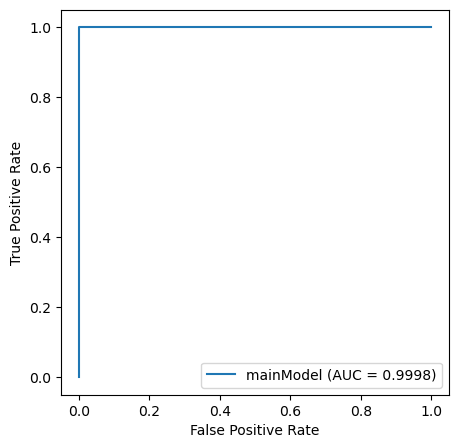

In [9]:
#plot the roc curve
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(5, 5))
for name, model in models.items():
    prob = predict_prob(model, X_test, edge_index, 76,device='cuda')  # 或 'cpu'

    y_true = Y_test.view(-1).cpu().numpy()
    y_score = prob.view(-1, 2)[:, 1].cpu().numpy()
    print(f"{name} - y_true samples: {len(y_true)}, y_score samples: {len(y_score)}")
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label='{} (AUC = {:.4f})'.format(model.name, roc_auc))
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()


In [10]:
metrics = evaluate_performance(models, X_test, Y_test, edge_index, device)
df = pd.DataFrame(metrics)
print(df)

       model    TN  FP  FN  TP precision  recall      f1     auc     fpr  \
0  mainModel  3672   5   0  73    0.9679  0.9993  0.9831  0.9998  0.0014   

      fnr loss_train loss_val acc_train acc_val accuracy  
0  0.0000     0.0098   0.0182    0.9988  0.9971   0.9987  


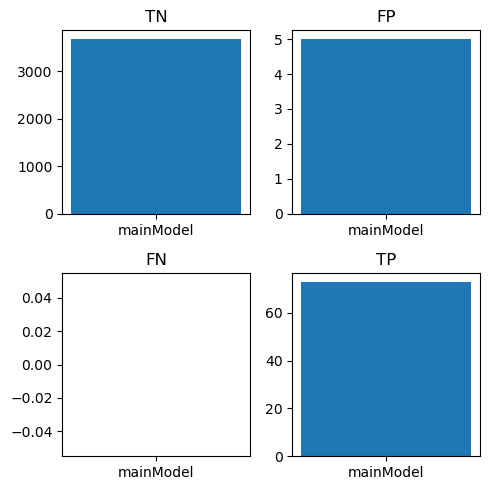

In [11]:
# plot the TP, FP, TN, FN for each model
fig, axs = plt.subplots(2, 2, figsize=(5, 5))
axs = axs.ravel()

bar_width = 0.5
labels = ['TN', 'FP', 'FN', 'TP']

for i, label in enumerate(labels):
    for j, name in enumerate(models):
        rects = axs[i].bar(j, metrics[j][label], width=bar_width, label=name)
    axs[i].set_xticks(np.arange(len(models)))
    axs[i].set_xticklabels(models.keys())
    for tick in axs[i].xaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
    axs[i].set_title(label)

handles, labels = axs[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()



In [12]:
# robustness evaluation
for i in range(Y_test.shape[0]):
    for j in range(len(action_mask)):
        if Y_test[i, j] == 1:
            for k in range(76):
                X_test[i, action_mask[j],-76+k] += torch.normal(mean=0, std=0.01, size=(1,)).item()

metrics = evaluate_performance(models, X_test, Y_test, edge_index, device)
df = pd.DataFrame(metrics)
print(df)

       model    TN  FP  FN  TP precision  recall      f1     auc     fpr  \
0  mainModel  3672   5   0  73    0.9679  0.9993  0.9831  0.9999  0.0014   

      fnr loss_train loss_val acc_train acc_val accuracy  
0  0.0000     0.0098   0.0182    0.9988  0.9971   0.9987  


In [13]:
from torch_geometric.data import Data
from torch_geometric.explain import GNNExplainer, Explainer

# individual case analysis
found = False
while not found:
    indi_case_id = torch.randint(0, X_test.shape[0], (1,)).item()
    y_true = Y_test[indi_case_id]
    if y_true[2] != 0:
        found = True
        print('indi_case_id: ', indi_case_id)
indi_case_x = X_test[indi_case_id]

indi_case_id:  224


In [14]:
# # Explainability visualization
#
# model_to_explain = model_GCN_EW
# model_to_explain.eval()
# if model.name in ['GAT']:
#     indi_case_x = indi_case_x.view(-1, in_dim)
# prob_ts = torch.sigmoid(model_to_explain(indi_case_x, edge_index))[action_mask]
#
# print('model prob_ts: \n', prob_ts)
# print('y_true: ', y_true)
#
# data = Data(x=X_test[indi_case_id], edge_index=edge_index)
#
# explainer = Explainer(
#     model=model_to_explain,
#     algorithm=GNNExplainer(epochs=200),
#     explanation_type='model',
#     node_mask_type='attributes',
#     edge_mask_type='object',
#     model_config=dict(
#         mode='binary_classification',
#         task_level='node',
#         return_type='raw',
#     ),
#
# )
#
# feat_labels_ag = corpus.dictionary.idx2word.values()
# feat_labels_ag = list(feat_labels_ag)
# feat_labels_rtm = pd.read_csv('../datasets/public/CICIDS-2017.csv').columns.tolist()[:-1]
# feat_labels_rtm = [feat.strip() for feat in feat_labels_rtm]
# feat_labels = feat_labels_ag + feat_labels_rtm
#
# compromised_node = action_node_idx[np.where(y_true==1)[0].item()]
# explanation = explainer(data.x, data.edge_index, index=compromised_node)
#
# explanation.visualize_feature_importance(feat_labels=feat_labels, top_k=10)
# explanation.visualize_graph()

In [15]:
# ==================== Inference Time Measurement ====================
def measure_inference_time(model, X, edge_index, num_runs=100, device='cuda'):
    """
    Measure average inference time per sample (graph).
    Args:
        model: trained PyTorch model
        X: input tensor of shape (N_graphs, num_nodes, feat_dim)
        edge_index: graph edge index
        num_runs: number of forward passes to average over
        device: 'cuda' or 'cpu'
    Returns:
        avg_time_per_sample: in seconds
    """
    model.eval()
    X = X.to(device)
    edge_index = edge_index.to(device)

    # Warm-up run
    with torch.no_grad():
        _ = model(X[0].unsqueeze(0), edge_index)

    if device == 'cuda':
        torch.cuda.synchronize()  # 确保 GPU 操作完成

    start_time = time.time()

    with torch.no_grad():
        for i in range(num_runs):
            # 随机选一个样本（或固定第一个），避免缓存影响
            idx = i % X.size(0)
            _ = model(X[idx].unsqueeze(0), edge_index)

    if device == 'cuda':
        torch.cuda.synchronize()

    total_time = time.time() - start_time
    avg_time_per_sample = total_time / num_runs
    return avg_time_per_sample


# 在你的模型评估循环中加入推理时间
print("\n========== Inference Time (per graph) ==========")
inference_times = {}
for name, model in models.items():
    avg_time = measure_inference_time(model, X_test, edge_index, num_runs=200, device=device)
    inference_times[name] = avg_time
    print(f"{name}: {avg_time * 1000:.3f} ms per graph")
print()


========== Inference Time (per graph) ==========
mainModel: 3.168 ms per graph



In [16]:
# --- 插入位置：gnn_ids_dataset2.ipynb 末尾 ---
import time

def profile_inference(model, X, edge_index, device, num_iterations=100):
    model.eval()
    X, edge_index = X.to(device), edge_index.to(device)

    # 预热 (Warm-up)
    with torch.no_grad():
        for _ in range(10):
            _ = model(X, edge_index)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(X, edge_index)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        peak_inf_mem = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        peak_inf_mem = 0

    elapsed_time = time.time() - start_time

    # 吞吐量计算：总样本数 / 总时间
    # 假设每次推理处理的是整个图（或者是 X.size(0) 个节点）
    total_samples = X.size(0) * num_iterations
    throughput = total_samples / elapsed_time

    return throughput, peak_inf_mem

# 调用示例
print(f"{'Model':<12} | {'Throughput (nodes/s)':<20} | {'Inference Mem (MB)':<15}")
for name, model in models.items():
    thru, mem = profile_inference(model, X_test, edge_index, device)
    print(f"{name:<12} | {thru:>20.2f} | {mem:>15.2f}")

Model        | Throughput (nodes/s) | Inference Mem (MB)
mainModel    |              6602.15 |         3677.45
